In [134]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
# !unzip train.zip
# !unzip drive/MyDrive/ssne_datasets/trafic_32.zip

In [136]:
# %load_ext autoreload
# %autoreload 2

In [152]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgb
import matplotlib

## PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.optim import Adam

import importlib
from modele import BasicUNet
import vae
import utils
# from utils import train, generate_random_images, save_images, save_model, corrupt

In [153]:

importlib.reload(vae)
importlib.reload(utils)

<module 'utils' from '/content/utils.py'>

In [139]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [140]:
TRAIN_DATA_DIR = "trafic_32"
BATCH_SIZE = 16
OVERFIT_ON_FIRST_BATCH = False

transform = transforms.Compose([transforms.ToTensor()])
dataset = ImageFolder(TRAIN_DATA_DIR, transform=transform)
loader = DataLoader(
    dataset,
    BATCH_SIZE,
    shuffle=not OVERFIT_ON_FIRST_BATCH,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [141]:
number_of_classes = 43
all_classes = np.arange(number_of_classes, dtype=int)
class_to_idx = {c: i for i, c in enumerate(all_classes)}

idx = torch.tensor([class_to_idx[x] for x in all_classes])

onehot = nn.functional.one_hot(idx, num_classes=len(all_classes))

print(onehot[torch.tensor([0, 1, 2])])

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [142]:
for images, labels in loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([16, 3, 32, 32])
torch.Size([16])


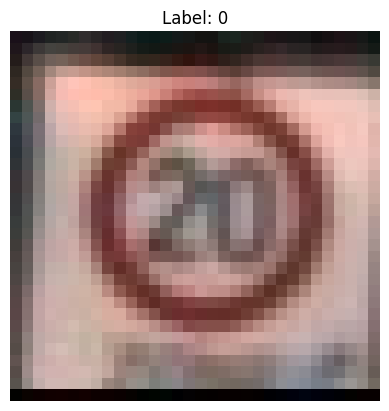

In [143]:
image, label = dataset[100]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Input shape: torch.Size([8, 3, 32, 32])


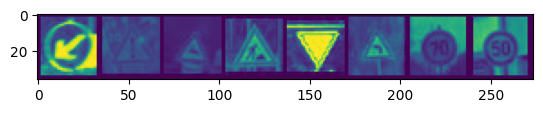

In [144]:
x, y = next(iter(loader))
x = x[:8]
print('Input shape:', x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0]);

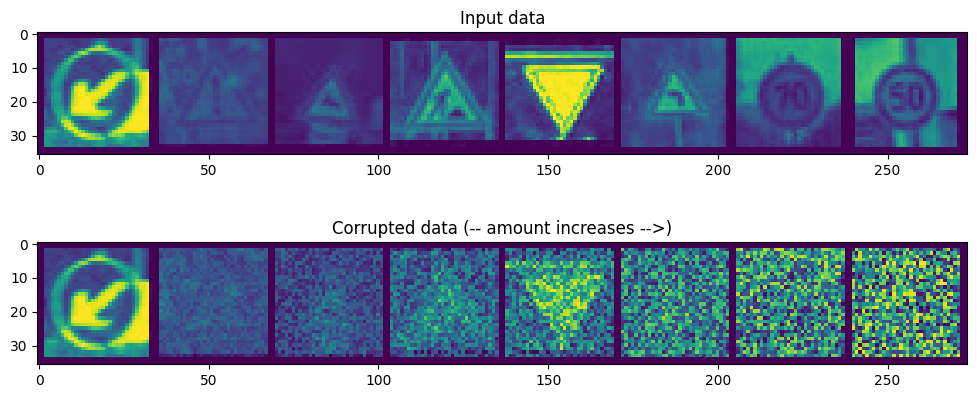

In [145]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0])

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0]);

In [146]:
vae_m = vae.VAE(
    input_dim=3 * 32 * 32,
    hidden_dim=1024,
    latent_dim=128,
    output_dim=3 * 32 * 32,
    condition_size=onehot.shape[0],
).to(device)
optimizer = Adam(vae_m.parameters(), lr=0.0003)
vae_m


VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=3115, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mean): Linear(in_features=1024, out_features=128, bias=True)
    (fc_log_std): Linear(in_features=1024, out_features=128, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=171, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=3072, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
)

[1/5], Loss: 1.16e+03
[2/5], Loss: 9.9e+02
[3/5], Loss: 9.26e+02
[4/5], Loss: 8.92e+02
[5/5], Loss: 8.65e+02


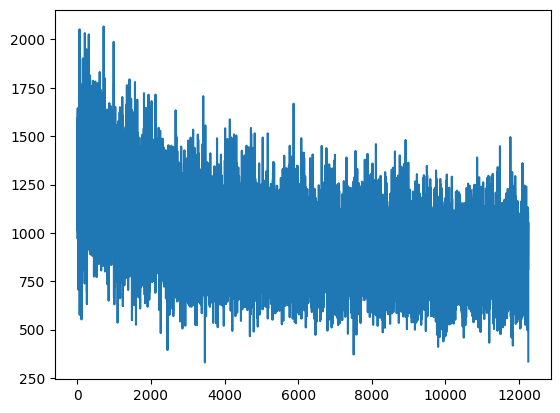

In [148]:
EPOCHS = 5
losses = []

utils.train(
    model=vae_m,
    optimizer=optimizer,
    loader=loader,
    onehot=onehot,
    overfit_on_single_batch=OVERFIT_ON_FIRST_BATCH,
    epochs=EPOCHS,
    show_every=1,
    losses_list=losses,
    device=device,
)

plt.plot(losses)
plt.show()

In [ ]:
save_model(vae, "output/vae_model.pt")

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(20, 10))
img = next(iter(loader))[0].to(device)
recon = vae(img)[0]
axs[0].imshow(recon[0].permute(1, 2, 0).cpu().detach())
axs[0].set_title("vae")
axs[0].axis("off")
axs[1].imshow(img[0].permute(1, 2, 0).cpu().detach())
axs[1].set_title("real")
axs[1].axis("off")
plt.show()

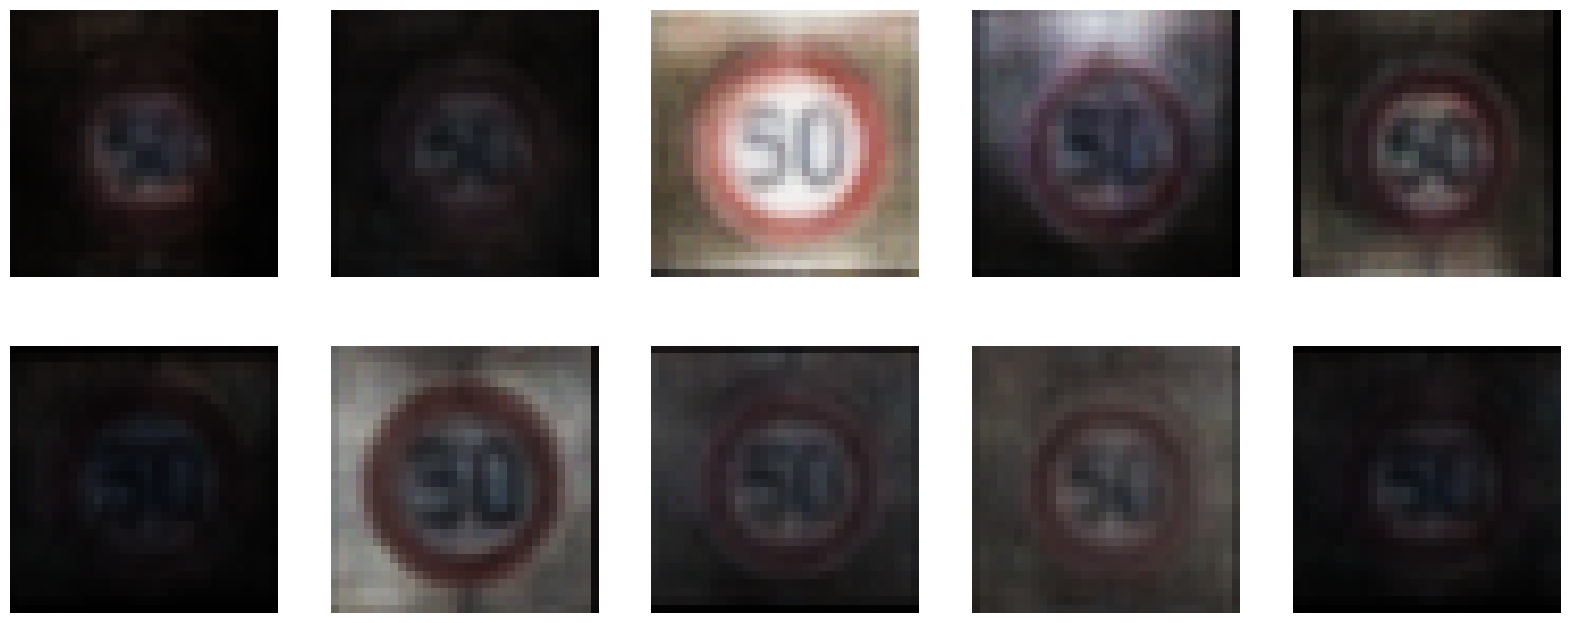

In [156]:
num_imgs = 10
imgs = utils.generate_random_images(
    model=vae_m,
    onehot=onehot,
    classes=np.ones(num_imgs, dtype=int)*2,
    num_imgs=num_imgs,
    device=device)
_, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()
for a, img in zip(axs, imgs):
    a.imshow(img.permute(1, 2, 0).cpu().detach())
    a.axis("off")
plt.show()

In [ ]:
imgs_final = generate_random_images(vae, 1000, device=device)
save_images(imgs_final, "output/generated_vae.pt")
imgs_final.shape